# Task 4: Spam SMS Detection

## Step 1: Import Required Libraries

In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

## Step 2: Load the Dataset

In [4]:
df = pd.read_csv("spam.csv", encoding='latin-1')

In [5]:
print(df.head())
print(df.shape)

     v1                                                 v2 Unnamed: 2  \
0   ham  Go until jurong point, crazy.. Available only ...        NaN   
1   ham                      Ok lar... Joking wif u oni...        NaN   
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...        NaN   
3   ham  U dun say so early hor... U c already then say...        NaN   
4   ham  Nah I don't think he goes to usf, he lives aro...        NaN   

  Unnamed: 3 Unnamed: 4  
0        NaN        NaN  
1        NaN        NaN  
2        NaN        NaN  
3        NaN        NaN  
4        NaN        NaN  
(5572, 5)


## Step 3: Keep Required Columns

In [6]:
df = df[['v1', 'v2']]
df.columns = ['label', 'message']

## Step 4: Convert Labels into Numbers

In [7]:
df['label'] = df['label'].map({
    'ham': 0,
    'spam': 1
})

In [8]:
print(df['label'].value_counts())

label
0    4825
1     747
Name: count, dtype: int64


## Step 5: Define Features and Target

In [9]:
X = df['message']
y = df['label']

## Step 6: Split Dataset

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

## Step 7: Convert Text to Numerical Features

In [11]:
vectorizer = TfidfVectorizer(stop_words='english')

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

## Step 8: Train the Model

In [14]:
model = MultinomialNB()

model.fit(X_train_tfidf, y_train)

MultinomialNB()

## Step 9: Make Predictions

In [15]:
y_pred = model.predict(X_test_tfidf)

## Step 10: Evaluate Model

In [20]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.9668161434977578

Classification Report:
              precision    recall  f1-score   support

           0       0.96      1.00      0.98       965
           1       1.00      0.75      0.86       150

    accuracy                           0.97      1115
   macro avg       0.98      0.88      0.92      1115
weighted avg       0.97      0.97      0.96      1115



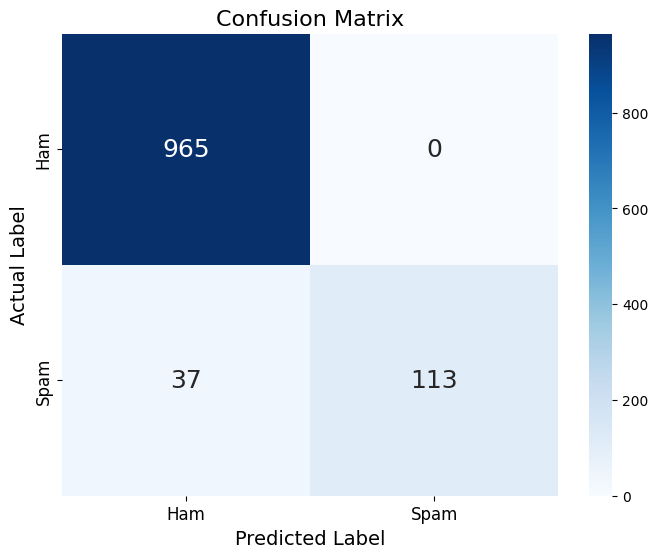

In [19]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Ham', 'Spam'],
    yticklabels=['Ham', 'Spam'],
    annot_kws={"size": 18}
)

plt.xlabel('Predicted Label', fontsize=14)
plt.ylabel('Actual Label', fontsize=14)
plt.title('Confusion Matrix', fontsize=16)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.show()

## Step 11: Test with Custom Messages

In [17]:
sample = ["Congratulations! You have won a free iPhone. Claim now."]

sample_vector = vectorizer.transform(sample)

prediction = model.predict(sample_vector)

if prediction[0] == 1:
    print("Spam Message")
else:
    print("Not Spam")

Spam Message


## Step 12: Save the Model

In [18]:
import pickle

pickle.dump(model, open("spam_model.pkl", "wb"))
pickle.dump(vectorizer, open("tfidf_vectorizer.pkl", "wb"))

## Conclusion

A Spam SMS Detection system was successfully developed using Natural Language Processing and Machine Learning techniques. Text messages were transformed into numerical features using TF-IDF Vectorization and classified using the Multinomial Naive Bayes algorithm. The model achieved an accuracy of 96.68%, demonstrating its effectiveness in identifying spam messages. This project highlights the practical application of machine learning in text classification and spam filtering systems.